# 全景
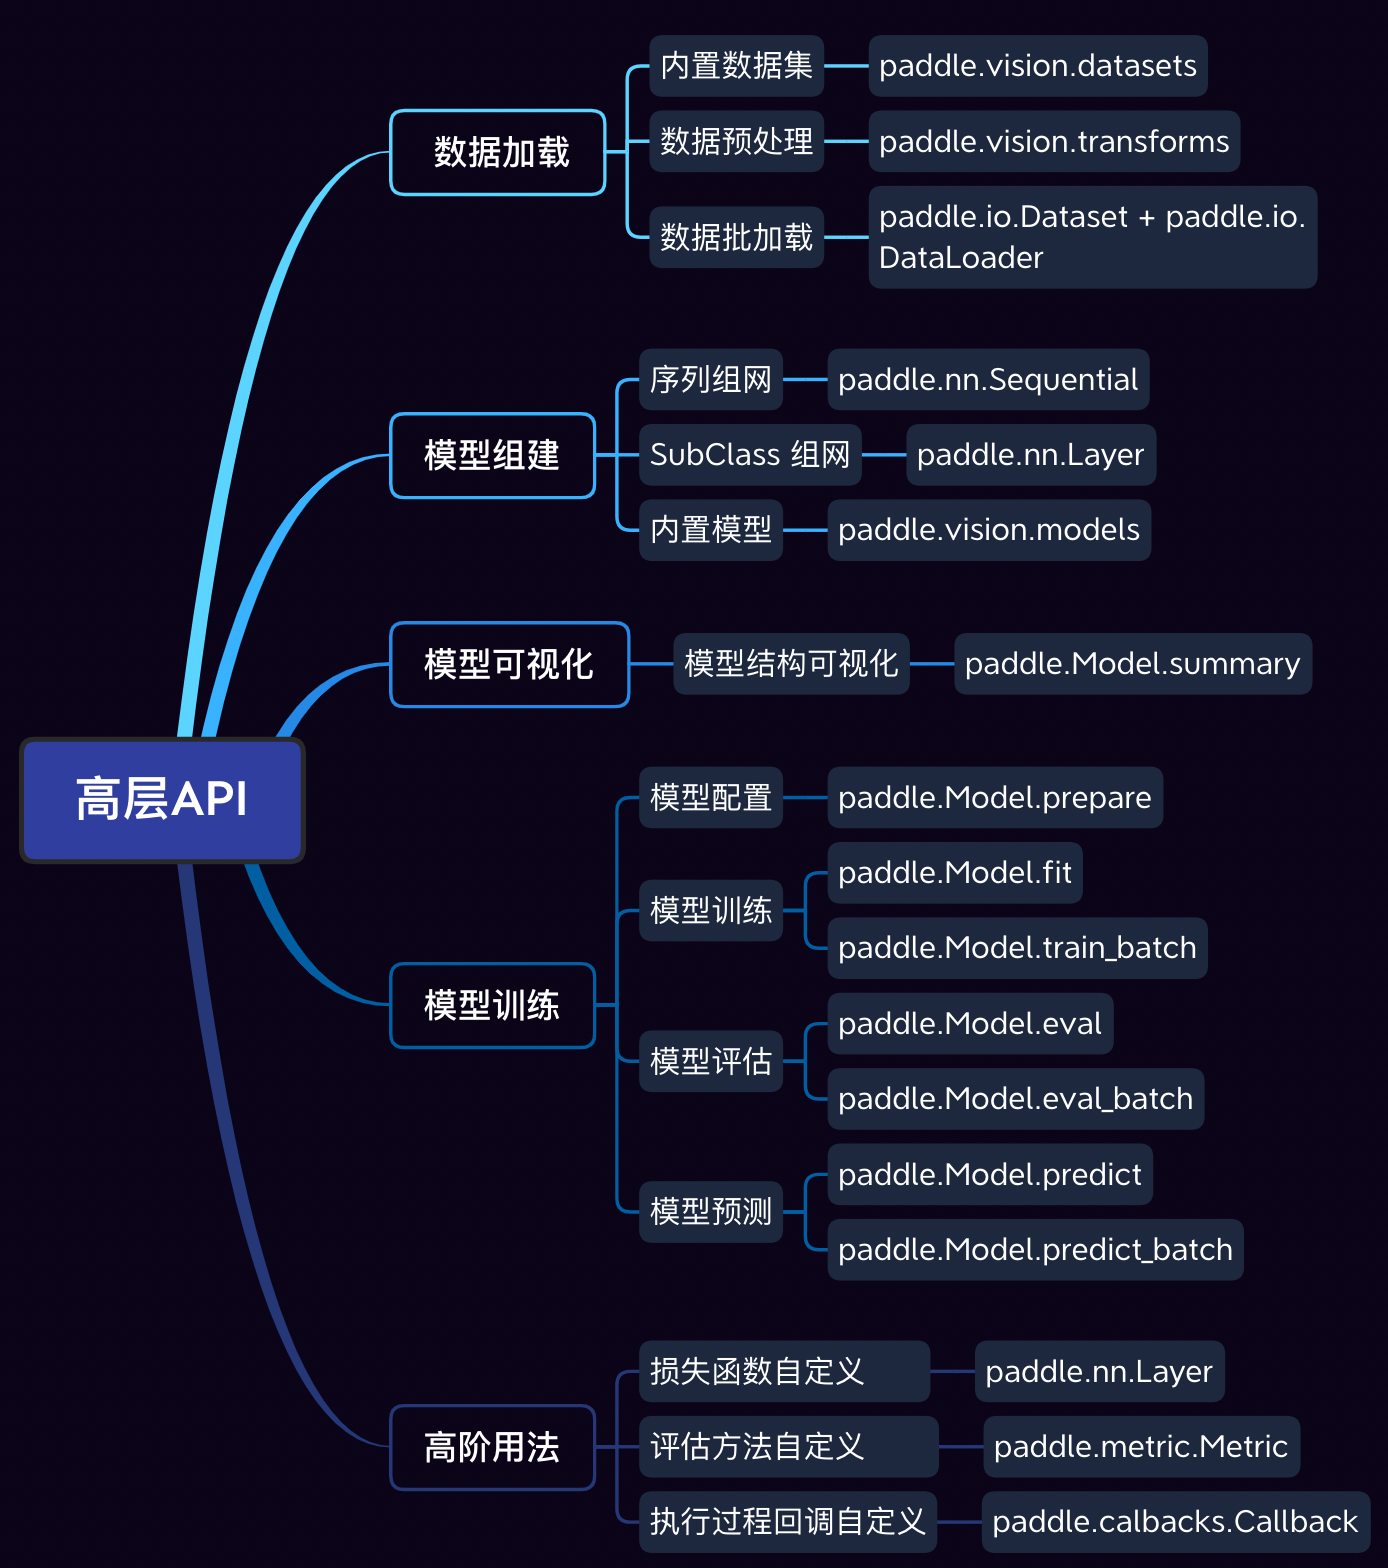

# 数据管道
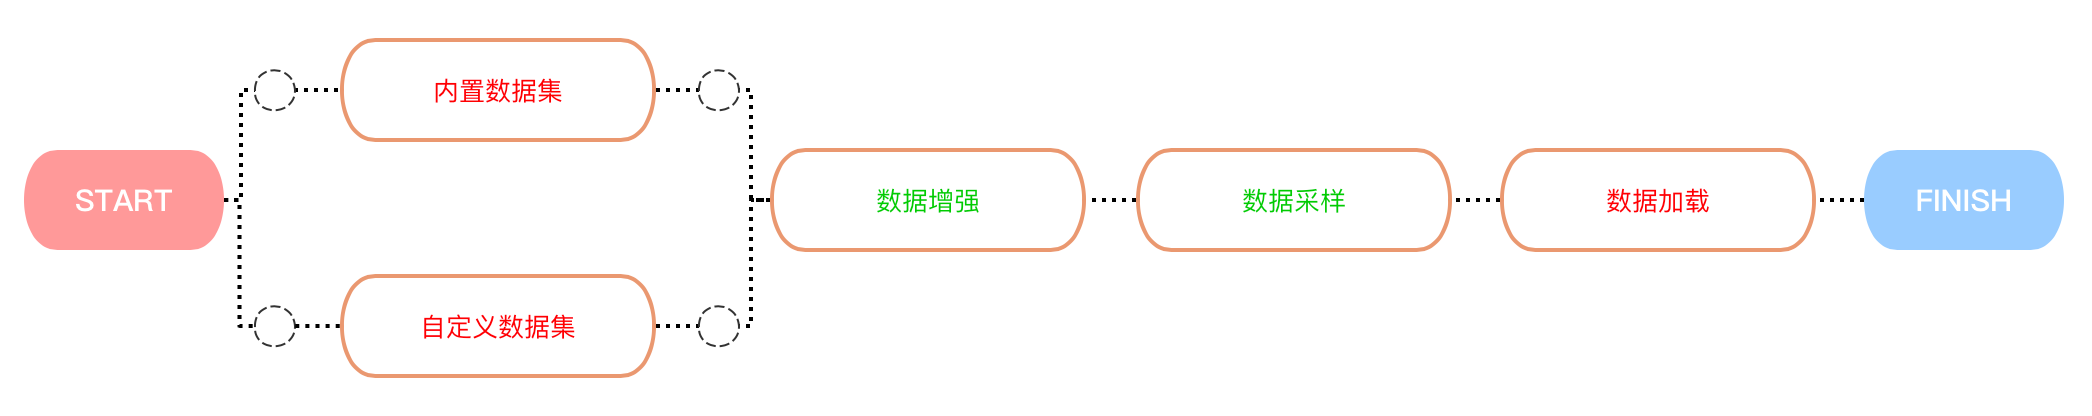

- dataset---> dataloader(sample)->for
- dataset---> fit

## 内置数据集

/home/lin/miniconda3/envs/paddle/lib/python3.8/site-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


['DatasetFolder', 'ImageFolder', 'MNIST', 'FashionMNIST', 'Flowers', 'Cifar10', 'Cifar100', 'VOC2012']
['Conll05st', 'Imdb', 'Imikolov', 'Movielens', 'UCIHousing', 'WMT14', 'WMT16']


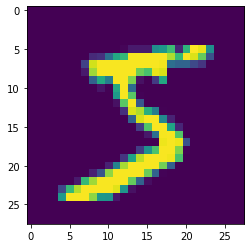

[5]


In [5]:
# 内置
print(paddle.vision.datasets.__all__)
print(paddle.text.datasets.__all__)
train_dataset = paddle.vision.datasets.MNIST(mode="train")
test_dataset = paddle.vision.datasets.MNIST(mode="test")

import numpy as np
import matplotlib.pyplot as plt


plt.imshow(train_dataset[0][0])
plt.show()
print(train_dataset[0][1])

## 自定义数据集
- paddle.io.Dataset Map-style
- paddle.io.IterableDataset Iterable-style 
- paddle.io.TensorDataset Tensor

### map-style

In [11]:
from paddle.io import Dataset
import numpy as np

class MyDataset(Dataset):
    def __init__(self, mode):
        super(MyDataset, self).__init__()
        if mode == "train":
            self.data = [[x,y] for x,y in zip(range(10), range(10))]
        elif mode == "test":
            self.data = [[x,y] for x,y in zip(range(10,0,-1), range(10,0,-1))]

    def __getitem__(self, idx):
        return self.data[idx]

    def __len__(self):
        return len(self.data)

train = MyDataset(mode="train")
for d,l in train:
    print(d, l)

print("\n")

test = MyDataset(mode="test")
for d,l in test:
    print(d,l)

0 0
1 1
2 2
3 3
4 4
5 5
6 6
7 7
8 8
9 9


10 10
9 9
8 8
7 7
6 6
5 5
4 4
3 3
2 2
1 1


In [ ]:
# # 下载训练集
# !wget http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/train-images-idx3-ubyte.gz
# # 下载训练集标签
# !wget http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/train-labels-idx1-ubyte.gz
# # 下载测试集
# !wget http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/t10k-images-idx3-ubyte.gz
# # 下载测试集标签
# !wget http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/t10k-labels-idx1-ubyte.gz

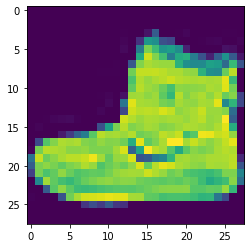

9


In [9]:
import os 
import gzip
import matplotlib.pyplot as plt

class FashionMNISTDataset(paddle.io.Dataset):
    """
    步骤一：继承paddle.io.Dataset类
    """
    def __init__(self, path='./', mode='train'):
        """
        步骤二：实现构造函数，定义数据读取方式，划分训练和测试数据集
        """
        super(FashionMNISTDataset, self).__init__()

        images_data_path = os.path.join(path, '%s-images-idx3-ubyte.gz' % mode)
        labels_data_path = os.path.join(path,'%s-labels-idx1-ubyte.gz' % mode)
        with gzip.open(labels_data_path, 'rb') as lbpath:
            self.labels = np.frombuffer(lbpath.read(), dtype=np.uint8, offset=8)

        with gzip.open(images_data_path, 'rb') as imgpath:
            self.images = np.frombuffer(imgpath.read(), dtype=np.uint8, offset=16).reshape(len(self.labels), 784)

    def __getitem__(self, index):
        """
        步骤三：实现__getitem__方法，定义指定index时如何获取数据，并返回单条数据（训练数据，对应的标签）
        """
        image = self.images[index]
        label = self.labels[index]

        return image, label

    def __len__(self):
        """
        步骤四：实现__len__方法，返回数据集总数目
        """
        return len(self.images)

train_data = FashionMNISTDataset(mode="train")
t10k_data = FashionMNISTDataset(mode="t10k")

img, lab = train_data[0]
img = img.reshape(28, 28)
plt.imshow(img)
plt.show()
print(lab)

### iterable-style

In [12]:
import math
import paddle
import numpy as np
from paddle.io import IterableDataset, DataLoader, get_worker_info

class SplitedIterableDataset(IterableDataset):
    """
    步骤一：继承paddle.io.Dataset类
    """
    def __init__(self, start, end):
        self.start = start
        self.end = end
    
    def __iter__(self):
        """
        步骤二：实现__iter__方法，
        """    
        worker_info = get_worker_info()
        if worker_info is None:
            iter_start = self.start
            iter_end = self.end
        else:
            per_worker = int(math.ceil((self.end - self.start) / worker_info.num_workers))
            worker_id = worker_info.id
            iter_start = self.start + worker_id * per_worker
            iter_end = min(iter_start + per_worker, self.end)
        
        for i in range(iter_start, iter_end):
            yield np.array([i])


dataset = SplitedIterableDataset(start=2, end=9)
dataloader = DataLoader(dataset, num_workers=2, batch_size=1, drop_last=True)

for data in dataloader:
    print(data[0].numpy())

[[2]]
[[6]]
[[3]]
[[7]]
[[4]]
[[8]]
[[5]]


### tensor

In [16]:
# TODO

## 采样
TODO 这玩意怎么放进pipeline里?

In [14]:
from paddle.io import SequenceSampler, RandomSampler, BatchSampler, DistributedBatchSampler

class RandomDataset(paddle.io.Dataset):
    def __init__(self, num_samples):
        self.num_samples = num_samples

    def __getitem__(self, idx):
        image = np.random.random([784]).astype('float32')
        label = np.random.randint(0, 9, (1, )).astype('int64')
        return image, label

    def __len__(self):
        return self.num_samples
    
train_dataset = RandomDataset(100)

print('-----------------顺序采样----------------')
sampler = SequenceSampler(train_dataset)
batch_sampler = BatchSampler(sampler=sampler, batch_size=10)

for index in batch_sampler:
    print(index)
    
print('-----------------随机采样----------------')
sampler = RandomSampler(train_dataset)
batch_sampler = BatchSampler(sampler=sampler, batch_size=10)

for index in batch_sampler:
    print(index)

print('-----------------分布式采样----------------')
batch_sampler = DistributedBatchSampler(train_dataset, num_replicas=2, batch_size=10)

for index in batch_sampler:
    print(index)
    

-----------------顺序采样----------------
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
[20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
[30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
[40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
[50, 51, 52, 53, 54, 55, 56, 57, 58, 59]
[60, 61, 62, 63, 64, 65, 66, 67, 68, 69]
[70, 71, 72, 73, 74, 75, 76, 77, 78, 79]
[80, 81, 82, 83, 84, 85, 86, 87, 88, 89]
[90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
-----------------随机采样----------------
[24, 90, 91, 23, 20, 18, 7, 93, 66, 31]
[81, 52, 38, 14, 10, 29, 83, 76, 87, 9]
[88, 69, 47, 17, 16, 27, 30, 49, 89, 46]
[62, 72, 80, 13, 67, 98, 44, 34, 15, 85]
[56, 63, 58, 86, 94, 33, 97, 70, 28, 36]
[48, 51, 59, 41, 11, 35, 65, 6, 22, 2]
[92, 5, 60, 4, 99, 74, 53, 26, 45, 55]
[39, 1, 64, 0, 32, 3, 21, 78, 12, 75]
[57, 43, 73, 19, 37, 68, 61, 25, 54, 71]
[40, 82, 8, 95, 77, 84, 96, 79, 50, 42]
-----------------分布式采样----------------
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
[40, 41, 42, 

## 数据增强

['BaseTransform', 'Compose', 'Resize', 'RandomResizedCrop', 'CenterCrop', 'RandomHorizontalFlip', 'RandomVerticalFlip', 'Transpose', 'Normalize', 'BrightnessTransform', 'SaturationTransform', 'ContrastTransform', 'HueTransform', 'ColorJitter', 'RandomCrop', 'Pad', 'RandomRotation', 'Grayscale', 'ToTensor', 'to_tensor', 'hflip', 'vflip', 'resize', 'pad', 'rotate', 'to_grayscale', 'crop', 'center_crop', 'adjust_brightness', 'adjust_contrast', 'adjust_hue', 'normalize']


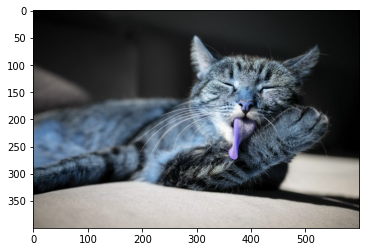

In [3]:
import cv2
import paddle
from paddle.vision.transforms import Compose, RandomHorizontalFlip, RandomVerticalFlip
import matplotlib.pyplot as plt

print(paddle.vision.transforms.__all__)

class MyDataset(paddle.io.Dataset):
    def __init__(self, mode, transforms):
        self.data = [["cat.jpg", 0]]
        if isinstance(transforms, list):
            transforms = Compose(transforms)
        self.transforms = transforms
        
    def __getitem__(self, idx):
        img = self.data[idx][0]
        lab = self.data[idx][1]
        img = cv2.imread(img) # TODO:图片读取有问题
        img = self.transforms(img)
        return img, lab
        
    def __len__(self):
        return len(self.data)

data = MyDataset(mode="train", transforms=[RandomHorizontalFlip(), RandomVerticalFlip()])
img, lab = data[0]
plt.imshow(img)
plt.show() 

from paddle.vision.transforms import hflip
img = cv2.imread("./cat.jpg")
img = hflip(img)

# 模型搭建

## 内置模型

In [54]:
print(paddle.vision.models.__all__)

import paddle
from paddle.vision.datasets import MNIST
from paddle.vision.transforms import Normalize

transform = Normalize(mean=[127.5], std=[127.5], data_format="CHW")

train_dataset = MNIST(mode="train", transform=transform)
test_dataset = MNIST(mode="test", transform=transform)

mnist = paddle.vision.models.LeNet(num_classes=10)
paddle.summary(mnist, (64, 1, 28, 28))
model = paddle.Model(mnist)

model.prepare(
    optimizer=paddle.optimizer.Adam(learning_rate=0.001, parameters=model.parameters()),
    loss=paddle.nn.CrossEntropyLoss(),
    metrics=paddle.metric.Accuracy()
)

model.fit(
    train_dataset,
    epochs=1,
    batch_size=64,
    verbose=1
)

model.evaluate(
    test_dataset,
    batch_size=64,
    verbose=1
)


['ResNet', 'resnet18', 'resnet34', 'resnet50', 'resnet101', 'resnet152', 'VGG', 'vgg11', 'vgg13', 'vgg16', 'vgg19', 'MobileNetV1', 'mobilenet_v1', 'MobileNetV2', 'mobilenet_v2', 'LeNet']
---------------------------------------------------------------------------
 Layer (type)       Input Shape          Output Shape         Param #    
  Conv2D-153     [[64, 1, 28, 28]]     [64, 6, 28, 28]          60       
    ReLU-88      [[64, 6, 28, 28]]     [64, 6, 28, 28]           0       
 MaxPool2D-39    [[64, 6, 28, 28]]     [64, 6, 14, 14]           0       
  Conv2D-154     [[64, 6, 14, 14]]     [64, 16, 10, 10]        2,416     
    ReLU-89      [[64, 16, 10, 10]]    [64, 16, 10, 10]          0       
 MaxPool2D-40    [[64, 16, 10, 10]]     [64, 16, 5, 5]           0       
   Linear-67        [[64, 400]]           [64, 120]           48,120     
   Linear-68        [[64, 120]]            [64, 84]           10,164     
   Linear-69         [[64, 84]]            [64, 10]             850    

{'loss': [0.005841148], 'acc': 0.9743}

## Sequential

In [27]:
import paddle 
from paddle.vision.transforms import Compose, Normalize
from paddle.vision.datasets import MNIST
import paddle.nn as n
transform = Normalize(mean=[127.5], std=[127.5], data_format="CHW")

train_dataset = MNIST(mode="train", transform=transform)
test_dataset = MNIST(mode="test", transform=transform)

print(train_dataset[0][0].shape)

# sequential 构建模型
mnist = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, 10)
)

model.prepare(
    optimizer=paddle.optimizer.Adam(learning_rate=0.001, parameters=model.parameters()),
    loss=nn.CrossEntropyLoss(),
    metrics=paddle.metric.Accuracy()
)
model.fit(
    train_dataset,
    batch_size=64,
    epochs=1,
    verbose=1
)
model.evaluate(
    test_dataset,
    verbose=1
)

(1, 28, 28)
The loss value printed in the log is the current step, and the metric is the average value of previous step.
Epoch 1/1
step 938/938 [==============================] - loss: 0.0196 - acc: 0.9786 - 9ms/step          
Eval begin...
The loss value printed in the log is the current batch, and the metric is the average value of previous step.
step 10000/10000 [==============================] - loss: 2.9857e-04 - acc: 0.9812 - 3ms/step          
Eval samples: 10000


{'loss': [0.00029857468], 'acc': 0.9812}

## Subclass

In [28]:
import paddle 
from paddle.vision.transforms import Compose, Normalize
from paddle.vision.datasets import MNIST
import paddle.nn as nn
transform = Normalize(mean=[127.5], std=[127.5], data_format="CHW")

train_dataset = MNIST(mode="train", transform=transform)
test_dataset = MNIST(mode="test", transform=transform)

print(train_dataset[0][0].shape)


class MyModel(paddle.nn.Layer):
    def __init__(self):
        super(MyModel, self).__init__(name_scope="hand")
        self.flatten = nn.Flatten()
        self.linear_1 = nn.Linear(28*28, 512)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout()
        self.linear_2 = nn.Linear(512, 10)
    
    def forward(self, inputs):
        y = self.flatten(inputs)
        y = self.linear_1(y)
        y = self.relu(y)
        y = self.dropout(y)
        y = self.linear_2(y)
        return y

model.prepare(
    optimizer=paddle.optimizer.Adam(learning_rate=0.001, parameters=model.parameters()),
    loss=nn.CrossEntropyLoss(),
    metrics=paddle.metric.Accuracy()
)
model.fit(
    train_dataset,
    batch_size=64,
    epochs=1,
    verbose=1
)
model.evaluate(
    test_dataset,
    verbose=1
)

(1, 28, 28)
The loss value printed in the log is the current step, and the metric is the average value of previous step.
Epoch 1/1
step 938/938 [==============================] - loss: 0.0579 - acc: 0.9830 - 8ms/step          
Eval begin...
The loss value printed in the log is the current batch, and the metric is the average value of previous step.
step 10000/10000 [==============================] - loss: 4.1309e-04 - acc: 0.9790 - 3ms/step          
Eval samples: 10000


{'loss': [0.00041309407], 'acc': 0.979}

In [34]:
import paddle
import paddle.nn as nn

class MyModel(paddle.nn.Layer):
    def __init__(self, num_keypoints=15):
        super(MyModel, self).__init__()
        self.backbone = paddle.vision.models.resnet18()
        self.linear_1 = nn.Linear(1000, 512)
        self.linear_2 = nn.Linear(512, num_keypoints)
    
    def forward(self, inputs):
        y = self.backbone(inputs)
        y = self.linear_1(y)
        y = self.linear_2(y)
        return y

facenet = MyModel()
paddle.summary(model, (1, 3, 64, 64))
model = paddle.Model(facenet)

-------------------------------------------------------------------------------
   Layer (type)         Input Shape          Output Shape         Param #    
     Conv2D-23        [[1, 3, 64, 64]]     [1, 64, 32, 32]         9,408     
   BatchNorm2D-1     [[1, 64, 32, 32]]     [1, 64, 32, 32]          256      
      ReLU-24        [[1, 64, 32, 32]]     [1, 64, 32, 32]           0       
   MaxPool2D-23      [[1, 64, 32, 32]]     [1, 64, 16, 16]           0       
     Conv2D-24       [[1, 64, 16, 16]]     [1, 64, 16, 16]        36,864     
   BatchNorm2D-2     [[1, 64, 16, 16]]     [1, 64, 16, 16]          256      
      ReLU-25        [[1, 64, 16, 16]]     [1, 64, 16, 16]           0       
     Conv2D-25       [[1, 64, 16, 16]]     [1, 64, 16, 16]        36,864     
   BatchNorm2D-3     [[1, 64, 16, 16]]     [1, 64, 16, 16]          256      
   BasicBlock-1      [[1, 64, 16, 16]]     [1, 64, 16, 16]           0       
     Conv2D-26       [[1, 64, 16, 16]]     [1, 64, 16, 16]    

# 模型训练


## 高阶API

In [35]:
print(paddle.vision.models.__all__)

import paddle
from paddle.vision.datasets import MNIST
from paddle.vision.transforms import Normalize

transform = Normalize(mean=[127.5], std=[127.5], data_format="CHW")

train_dataset = MNIST(mode="train", transform=transform)
test_dataset = MNIST(mode="test", transform=transform)

mnist = paddle.vision.models.LeNet(num_classes=10)
model = paddle.Model(mnist)

model.prepare(
    optimizer=paddle.optimizer.Adam(learning_rate=0.001, parameters=model.parameters()),
    loss=paddle.nn.CrossEntropyLoss(),
    metrics=paddle.metric.Accuracy()
)

model.fit(
    train_dataset,
    epochs=1,
    batch_size=64,
    verbose=1
)

model.evaluate(
    test_dataset,
    batch_size=64,
    verbose=1
)

['ResNet', 'resnet18', 'resnet34', 'resnet50', 'resnet101', 'resnet152', 'VGG', 'vgg11', 'vgg13', 'vgg16', 'vgg19', 'MobileNetV1', 'mobilenet_v1', 'MobileNetV2', 'mobilenet_v2', 'LeNet']
The loss value printed in the log is the current step, and the metric is the average value of previous step.
Epoch 1/1
step 938/938 [==============================] - loss: 0.0215 - acc: 0.9492 - 9ms/step          
Eval begin...
The loss value printed in the log is the current batch, and the metric is the average value of previous step.
step 157/157 [==============================] - loss: 0.0038 - acc: 0.9760 - 8ms/step          
Eval samples: 10000


{'loss': [0.003803803], 'acc': 0.976}

## 单批训练

In [44]:
from tqdm import tqdm

train_loader = paddle.io.DataLoader(train_dataset, batch_size=64, shuffle=True)
for idx, data in tqdm(enumerate(train_loader())):
    model.train_batch([data[0]], [data[1]]) # 两个1d list,每个元素是一个batch的训练数据

test_loader = paddle.io.DataLoader(test_dataset, batch_size=64, shuffle=False, drop_last=True)
acc = 0
for idx, data in tqdm(enumerate(test_loader)):
    acc += model.eval_batch([data[0]], [data[1]])[1][0]
acc /= len(test_loader)
print(acc)

for idx, data in tqdm(enumerate(test_loader())):
    model.predict_batch([data[0]])

156it [00:01, 139.68it/s]
16it [00:00, 158.82it/s]

0.9848758012820513


156it [00:00, 162.48it/s]


## 低阶训练

In [1]:
import paddle
from paddle.vision.datasets import MNIST
from paddle.vision.transforms import Normalize

transform = Normalize(mean=[127.5], std=[127.5], data_format="CWH")

train_dataset = MNIST(mode="train", transform=transform)
test_dataset = MNIST(mode="test", transform=transform)

mnist = paddle.vision.models.LeNet(num_classes=10)

In [3]:
import paddle.nn.functional as F

train_loader = paddle.io.DataLoader(train_dataset, batch_size=64, shuffle=True)

def train(model):
    model.train()
    epochs=2
    optim = paddle.optimizer.Adam(learning_rate=0.001, parameters=model.parameters())
    for epoch in range(epochs):
        for batch_id, data in enumerate(train_loader()):
            x_data = data[0]
            y_data = data[1]
            predicts = model(x_data)
            loss = F.cross_entropy(predicts, y_data)
            loss.backward()
            acc = paddle.metric.accuracy(predicts, y_data)
            if batch_id % 500 == 0:
                print("epoch: {}, batch_id: {}, loss is: {}, acc is: {}".format(epoch, batch_id, loss.numpy(), acc.numpy()))
            optim.step()
            optim.clear_grad()
train(mnist)

epoch: 0, batch_id: 0, loss is: [0.04326163], acc is: [0.984375]
epoch: 0, batch_id: 500, loss is: [0.07387342], acc is: [0.96875]
epoch: 1, batch_id: 0, loss is: [0.06125624], acc is: [0.96875]
epoch: 1, batch_id: 500, loss is: [0.0060442], acc is: [1.]


低阶验证

In [8]:
test_loader = paddle.io.DataLoader(test_dataset, batch_size=64, shuffle=False, drop_last=True)
def test(model):
    model.eval()
    acc = 0
    for batch_id, data in enumerate(test_loader()):
        x = data[0]
        y = data[1]
        predicts = model(x)
        acc += paddle.metric.accuracy(predicts, y)
    acc /= len(test_loader())
    return acc
acc = test(mnist)
print(acc.numpy())

[0.98577726]


# 高阶用法

## 自定义Loss

In [ ]:
class SelfDefineLoss(paddle.nn.Layer):
    """
    1. 继承paddle.nn.Layer
    """
    def __init__(self):
        """
        2. 构造函数根据自己的实际算法需求和使用需求进行参数定义即可
        """
        super(SelfDefineLoss, self).__init__()

    def forward(self, input, label):
        """
        3. 实现forward函数，forward在调用时会传递两个参数：input和label
           - input：单个或批次训练数据经过模型前向计算输出结果
           - label：单个或批次训练数据对应的标签数据
           接口返回值是一个Tensor，根据自定义的逻辑加和或计算均值后的损失
        """
       # 使用Paddle中相关API自定义的计算逻辑
       # output = xxxxx
       # return output

In [ ]:
import paddle.nn.functional as F
class MyLoss(paddle.nn.Layer):
    def __init__(self):
        super(MyLoss, self).__init__()
    
    def forward(self, input, label):
        res = F.cross_entropy(input, label)
        print(res)
        return paddle.mead(res)

## 自定义Metric

In [ ]:
class SelfDefineMetric(paddle.metric.Metric):
    """
    1. 继承paddle.metric.Metric
    """
    def __init__(self):
        """
        2. 构造函数实现，自定义参数即可
        """
        super(SelfDefineMetric, self).__init__()

    def name(self):
        """
        3. 实现name方法，返回定义的评估指标名字
        """
        return '自定义评价指标的名字'

    def compute(self, *kwargs):
        """
        4. 本步骤可以省略，实现compute方法，这个方法主要用于`update`的加速，可以在这个方法中调用一些paddle实现好的Tensor计算API，编译到模型网络中一起使用低层C++ OP计算。
        """
        return '自己想要返回的数据，会做为update的参数传入。'

    def update(self, *kwargs):
        """
        5. 实现update方法，用于单个batch训练时进行评估指标计算。
        - 当`compute`类函数未实现时，会将模型的计算输出和标签数据的展平作为`update`的参数传入。
        - 当`compute`类函数做了实现时，会将compute的返回结果作为`update`的参数传入。
        """
        return 'acc value'

    def accumulate(self):
        """
        6. 实现accumulate方法，返回历史batch训练积累后计算得到的评价指标值。
        每次`update`调用时进行数据积累，`accumulate`计算时对积累的所有数据进行计算并返回。
        结算结果会在`fit`接口的训练日志中呈现。
        """
        # 利用update中积累的成员变量数据进行计算后返回
        return 'accumulated acc value'

    def reset(self):
        """
        7. 实现reset方法，每个Epoch结束后进行评估指标的重置，这样下个Epoch可以重新进行计算。
        """
        # do reset action

In [ ]:
from paddle.metric import Metric

class Precision(Metric):
    """
    Precision (also called positive predictive value) is the fraction of
    relevant instances among the retrieved instances. Refer to
    https://en.wikipedia.org/wiki/Evaluation_of_binary_classifiers
    Noted that this class manages the precision score only for binary
    classification task.

    ......
    """

    def __init__(self, name='precision', *args, **kwargs):
        super(Precision, self).__init__(*args, **kwargs)
        self.tp = 0  # true positive
        self.fp = 0  # false positive
        self._name = name

    def update(self, preds, labels):
        """
        Update the states based on the current mini-batch prediction results.
        Args:
            preds (numpy.ndarray): The prediction result, usually the output
               of two-class sigmoid function. It should be a vector (column
               vector or row vector) with data type: 'float64' or 'float32'.
           labels (numpy.ndarray): The ground truth (labels),
               the shape should keep the same as preds.
               The data type is 'int32' or 'int64'.
        """
        if isinstclass SelfDefineLoss(paddle.nn.Layer):
    """
    1. 继承paddle.nn.Layer
    """
    def __init__(self):
        """
        2. 构造函数根据自己的实际算法需求和使用需求进行参数定义即可
        """
        super(SelfDefineLoss, self).__init__()

    def forward(self, input, label):
        """
        3. 实现forward函数，forward在调用时会传递两个参数：input和label
           - input：单个或批次训练数据经过模型前向计算输出结果
           - label：单个或批次训练数据对应的标签数据
           接口返回值是一个Tensor，根据自定义的逻辑加和或计算均值后的损失
        """
       # 使用Paddle中相关API自定义的计算逻辑
       # output = xxxxx
       # return outputance(preds, paddle.Tensor):
            preds = preds.numpy()
        elif not _is_numpy_(preds):
            raise ValueError("The 'preds' must be a numpy ndarray or Tensor.")
        if isinstance(labels, paddle.Tensor):
            labels = labels.numpy()
        elif not _is_numpy_(labels):
            raise ValueError("The 'labels' must be a numpy ndarray or Tensor.")

        sample_num = labels.shape[0]
        preds = np.floor(preds + 0.5).astype("int32")

        for i in range(sample_num):
            pred = preds[i]
            label = labels[i]
            if pred == 1:
                if pred == label:
                    self.tp += 1
                else:
                    self.fp += 1

    def reset(self):
        """
        Resets all of the metric state.
        """
        self.tp = 0
        self.fp = 0

    def accumulate(self):
        """
        Calculate the final precision.

        Returns:
           A scaler float: results of the calculated precision.
        """
        ap = self.tp + self.fp
        return float(self.tp) / ap if ap != 0 else .0

    def name(self):
        """
        Returns metric name
        """
        return self._name

## 自定义CallBack

In [ ]:
class SelfDefineCallback(paddle.callbacks.Callback):
    """
    1. 继承paddle.callbacks.Callback
    2. 按照自己的需求实现以下类成员方法：
        def on_train_begin(self, logs=None)                 训练开始前，`Model.fit`接口中调用
        def on_train_end(self, logs=None)                   训练结束后，`Model.fit`接口中调用
        def on_eval_begin(self, logs=None)                  评估开始前，`Model.evaluate`接口调用
        def on_eval_end(self, logs=None)                    评估结束后，`Model.evaluate`接口调用
        def on_predict_begin(self, logs=None)               预测测试开始前，`Model.predict`接口中调用
        def on_predict_end(self, logs=None)                 预测测试结束后，`Model.predict`接口中调用
        def on_epoch_begin(self, epoch, logs=None)          每轮训练开始前，`Model.fit`接口中调用
        def on_epoch_end(self, epoch, logs=None)            每轮训练结束后，`Model.fit`接口中调用
        def on_train_batch_begin(self, step, logs=None)     单个Batch训练开始前，`Model.fit`和`Model.train_batch`接口中调用
        def on_train_batch_end(self, step, logs=None)       单个Batch训练结束后，`Model.fit`和`Model.train_batch`接口中调用
        def on_eval_batch_begin(self, step, logs=None)      单个Batch评估开始前，`Model.evalute`和`Model.eval_batch`接口中调用
        def on_eval_batch_end(self, step, logs=None)        单个Batch评估结束后，`Model.evalute`和`Model.eval_batch`接口中调用
        def on_predict_batch_begin(self, step, logs=None)   单个Batch预测测试开始前，`Model.predict`和`Model.predict_batch`接口中调用
        def on_predict_batch_end(self, step, logs=None)     单个Batch预测测试结束后，`Model.predict`和`Model.predict_batch`接口中调用
    """

    def __init__(self):
        super(SelfDefineCallback, self).__init__()
    # 按照需求定义自己的类成员方法

In [ ]:
class ModelCheckpoint(Callback):
    def __init__(self, save_freq=1, save_dir=None):
        self.save_freq = save_freq
        self.save_dir = save_dir

    def on_epoch_begin(self, epoch=None, logs=None):
        self.epoch = epoch

    def _is_save(self):
        return self.model and self.save_dir and ParallelEnv().local_rank == 0

    def on_epoch_end(self, epoch, logs=None):
        if self._is_save() and self.epoch % self.save_freq == 0:
            path = '{}/{}'.format(self.save_dir, epoch)
            print('save checkpoint at {}'.format(os.path.abspath(path)))
            self.model.save(path)

    def on_train_end(self, logs=None):
        if self._is_save():
            path = '{}/final'.format(self.save_dir)
            print('save checkpoint at {}'.format(os.path.abspath(path)))
            self.model.save(path)

## VisualDL

In [ ]:
callback = paddle.callbacks.VisualDL(log_dir='visualdl_log_dir')

In [ ]:
from visualdl import LogWriter

# 在`./log/scalar_test/train`路径下建立日志文件
with LogWriter(logdir="./log/scalar_test/train") as writer:
    # 使用scalar组件记录一个标量数据
    writer.add_scalar(tag="acc", step=1, value=0.5678)
    writer.add_scalar(tag="acc", step=2, value=0.6878)
    writer.add_scalar(tag="acc", step=3, value=0.9878)

# 模型保存和加载

In [ ]:
# TODO

# 例子

## 手写数字识别

In [20]:
import paddle
from paddle.vision.datasets import FashionMNIST
import paddle.nn as nn
from paddle.vision.transforms import Normalize
import paddle.nn.functional as F

transform = Normalize(mean=[127.5], std=[127.5], data_format="CHW")
train_dataset = FashionMNIST(mode="train", transform=transform)
test_dataset = FashionMNIST(mode="test", transform=transform)

class MyModel(paddle.nn.Layer):
    def __init__(self):
        super(MyModel, self).__init__()
        self.conv_1 = nn.Conv2D(in_channels=1, out_channels=4, kernel_size=5, stride=1, padding="SAME")
        self.pool_1 = nn.MaxPool2D(kernel_size=2, stride=2)
        self.conv_2 = nn.Conv2D(in_channels=4, out_channels=16, kernel_size=5, stride=1)
        self.pool_2 = nn.MaxPool2D(kernel_size=2, stride=2)
        self.flatten = nn.Flatten()
        self.linear_1 = nn.Linear(in_features=16*5*5, out_features=256)
        self.dropout = nn.Dropout(0.3)
        self.linear_2 = nn.Linear(in_features=256, out_features=10)
        
    def forward(self, inputs):
        y = self.conv_1(inputs)
        y = F.relu(y)
        y = self.pool_1(y)
        y = F.relu(y)
        y = self.conv_2(y)
        y = F.relu(y)
        y = self.pool_2(y)
        y = F.relu(y)
        y = self.flatten(y)
        y = self.linear_1(y)
        y = F.relu(y)
        y = self.dropout(y)
        y = F.relu(y)
        y = self.linear_2(y)
        y = F.softmax(y)
        return y

mnist = MyModel()
paddle.summary(mnist, (64,1,28,28))
model = paddle.Model(mnist)
model.prepare(
    optimizer=paddle.optimizer.Adam(parameters=model.parameters()),
    loss=nn.CrossEntropyLoss(),
    metrics=paddle.metric.Accuracy()
)
model.fit(
    train_dataset,
    batch_size=128,
    epochs=5,
    verbose=1
)
model.evaluate(
    test_dataset,
    batch_size=128,
    verbose=1
)
model.save('checkpoint/test')  # save for training
model.save('inference_model', training=False)  # save for inference

test_model = paddle.Model(mnist)
test_model.load("checkpoint/test", skip_mismatch=True, reset_optimizer=True)
test_model.prepare(
    optimizer=paddle.optimizer.Adam(parameters=model.parameters()),
    loss=nn.CrossEntropyLoss(),
    metrics=paddle.metric.Accuracy()
)
test_model.evaluate(
    test_dataset,
    batch_size=128,
    verbose=1
)

---------------------------------------------------------------------------
 Layer (type)       Input Shape          Output Shape         Param #    
   Conv2D-35     [[64, 1, 28, 28]]     [64, 4, 28, 28]          104      
 MaxPool2D-35    [[64, 4, 28, 28]]     [64, 4, 14, 14]           0       
   Conv2D-36     [[64, 4, 14, 14]]     [64, 16, 10, 10]        1,616     
 MaxPool2D-36    [[64, 16, 10, 10]]     [64, 16, 5, 5]           0       
  Flatten-11      [[64, 16, 5, 5]]        [64, 400]              0       
   Linear-23        [[64, 400]]           [64, 256]           102,656    
  Dropout-12        [[64, 256]]           [64, 256]              0       
   Linear-24        [[64, 256]]            [64, 10]            2,570     
Total params: 106,946
Trainable params: 106,946
Non-trainable params: 0
---------------------------------------------------------------------------
Input size (MB): 0.19
Forward/backward pass size (MB): 3.34
Params size (MB): 0.41
Estimated Total Size (MB): 

/home/lin/miniconda3/envs/paddle/lib/python3.8/site-packages/paddle/fluid/layers/utils.py:77: DeprecationWarning: Using or importing the ABCs from 'collections' instead of from 'collections.abc' is deprecated since Python 3.3, and in 3.9 it will stop working
  return (isinstance(seq, collections.Sequence) and


step 469/469 [==============================] - loss: 1.6015 - acc: 0.7671 - 14ms/step          
Epoch 2/5
step 469/469 [==============================] - loss: 1.6041 - acc: 0.8412 - 14ms/step          
Epoch 3/5
step 469/469 [==============================] - loss: 1.6183 - acc: 0.8585 - 13ms/step          
Epoch 4/5
step 469/469 [==============================] - loss: 1.6132 - acc: 0.8671 - 14ms/step          
Epoch 5/5
step 469/469 [==============================] - loss: 1.5585 - acc: 0.8752 - 13ms/step          
Eval begin...
The loss value printed in the log is the current batch, and the metric is the average value of previous step.
step 79/79 [==============================] - loss: 1.5996 - acc: 0.8666 - 12ms/step          
Eval samples: 10000


/home/lin/miniconda3/envs/paddle/lib/python3.8/site-packages/paddle/hapi/model.py:1736: UserWarning: 'inputs' was not specified when Model initialization, so the input shape to be saved will be the shape derived from the user's actual inputs. The input shape to be saved is [[128, 1, 28, 28]]. For saving correct input shapes, please provide 'inputs' for Model initialization.
  warnings.warn(


In [1]:
import paddle
from paddle.vision.datasets import FashionMNIST
from paddle.vision.transforms import Normalize, ToTensor
import paddle.nn as nn
import paddle.nn.functional as F
import matplotlib.pyplot as plt


transform = Normalize(mean=[127.5], std=[127.5], data_format="CHW")
train_dataset = FashionMNIST(mode="train", transform=transform)
test_dataset = FashionMNIST(mode="test", transform=ToTensor())

# d = train_dataset[0]
# plt.imshow(d[0])
# plt.show()

class MyModel(paddle.nn.Layer):
    def __init__(self):
        super(MyModel, self).__init__()
        self.conv_1 = nn.Conv2D(in_channels=1, out_channels=6, kernel_size=3, stride=1, padding="SAME")
        self.pool_1 = nn.MaxPool2D(kernel_size=2, stride=2)
        self.conv_2 = nn.Conv2D(in_channels=6, out_channels=16, kernel_size=3, stride=1)
        self.pool_2 = nn.MaxPool2D(kernel_size=2, stride=2)
        self.linear_1 = nn.Linear(in_features=16*6*6, out_features=120)
#         self.dropout_1 = nn.Dropout(0.1)
        self.linear_2 = nn.Linear(in_features=120, out_features=80)
#         self.dropout_2 = nn.Dropout(0.1)
        self.linear_3 = nn.Linear(in_features=80, out_features=10)
        
    def forward(self, inputs):
        y = self.conv_1(inputs)
        y = F.relu(y)
        y = self.pool_1(y)
        y = F.relu(y)
        y = self.conv_2(y)
        y = F.relu(y)
        y = self.pool_2(y)
        y = y.flatten(1, -1)
        y = self.linear_1(y)
#         y = self.dropout_1(y)
        y = self.linear_2(y)
#         y = self.dropout_2(y)
        y = self.linear_3(y)
        
        return y
    
# model = MyModel()
model = paddle.vision.models.LeNet()
paddle.summary(model, (1,1,28,28))

epochs = 10
optim = paddle.optimizer.Adam(learning_rate=0.001, parameters=model.parameters())
train_loader = paddle.io.DataLoader(train_dataset, batch_size=128, shuffle=True)
model.train()
for epoch in range(epochs):
    for batch_id, data in enumerate(train_loader()):
        x = data[0]
        y = data[1]
        predicts = model(x)
#         print(predicts.shape, y.shape)
        loss = F.cross_entropy(predicts, y)
        loss.backward()
        acc = paddle.metric.accuracy(predicts, y)
        if batch_id % 100 == 0:
            print("epoch: {}, batch_id: {}, loss is: {}, acc is: {}".format(epoch, batch_id, loss.numpy(), acc.numpy()))
        optim.step()
        optim.clear_grad()

model.eval()
test_loader = paddle.io.DataLoader(test_dataset, batch_size=128)
# metric = paddle.metric.Accuracy()
# for data in test_loader():
#     x = data[0]
#     y = data[1]
#     predicts = model(x)
#     metric.update(metric.compute(predicts, y))
# print(metric.accumulate())
    

acc = 0
for data in train_loader():
    x = data[0]
    y = data[1]
    predicts = model(x)
    acc += paddle.metric.accuracy(predicts, y)
acc /= len(train_loader())
print(acc.numpy())


acc = 0
for data in test_loader():
    x = data[0]
    y = data[1]
    predicts = model(x)
    acc += paddle.metric.accuracy(predicts, y)
acc /= len(test_loader())
print(acc.numpy())

        

---------------------------------------------------------------------------
 Layer (type)       Input Shape          Output Shape         Param #    
   Conv2D-1       [[1, 1, 28, 28]]      [1, 6, 28, 28]          60       
    ReLU-1        [[1, 6, 28, 28]]      [1, 6, 28, 28]           0       
  MaxPool2D-1     [[1, 6, 28, 28]]      [1, 6, 14, 14]           0       
   Conv2D-2       [[1, 6, 14, 14]]     [1, 16, 10, 10]         2,416     
    ReLU-2       [[1, 16, 10, 10]]     [1, 16, 10, 10]           0       
  MaxPool2D-2    [[1, 16, 10, 10]]      [1, 16, 5, 5]            0       
   Linear-1          [[1, 400]]            [1, 120]           48,120     
   Linear-2          [[1, 120]]            [1, 84]            10,164     
   Linear-3          [[1, 84]]             [1, 10]              850      
Total params: 61,610
Trainable params: 61,610
Non-trainable params: 0
---------------------------------------------------------------------------
Input size (MB): 0.00
Forward/backward